This script is intended to perform and register all the selection steps involved.
<br>
Here we are able to work at once Data and MC processed files with the following recipe:
- Load merged & tagged event/peak-level dataframe.
- Use HE scale and perform trigger02 efficiency cut.
- Select $nS2=1$ for fiducial events (electron-like).
- Select $ncluster=1$ for single track events.
- Update summary with event counter per run/isotope.
- Plot.

In [7]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import crudo

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import yaml

# Styling Plot
crudo.pt.ccortesp_plot_style()
# PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Configuration

In [8]:
# --- Notebook Parameters
VERSION_TAG = "LPR_p2_v2"
ANA_OPTIONS =  ['data', 'mc']
ANA_INFO = {opt:{} for opt in ANA_OPTIONS }

In [9]:
# -------------------
# LOAD CONFIGURATIONS
# -------------------
CONFIG_FILE = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/configs/low_bckg_analysis_config.yaml'

try:
    with open(CONFIG_FILE, 'r') as f:
        all_configs = yaml.safe_load(f)
except FileNotFoundError:
    raise FileNotFoundError(f"Configuration file '{CONFIG_FILE}' not found. Please check the path and try again.")

if VERSION_TAG not in all_configs:
    raise ValueError(f"Version tag '{VERSION_TAG}' not found in the configuration file. Available tags: {list(all_configs.keys())}")

# Set up the configuration
common_config = all_configs['common']
ana_config    = all_configs[VERSION_TAG]

for ana_type in ANA_OPTIONS:
    if ana_type in ana_config:
        print(f"{'-'*5} Loading configuration for {ana_type.upper()}")

        # Load directories and paths
        input_dir   = common_config['input_dir']
        summary_dir = common_config['summary_dir']
        input_path   = os.path.join(input_dir,   ana_config[ana_type]['processed_file'])
        summary_path = os.path.join(summary_dir, ana_config[ana_type]['summary_file'])
        print(f"  Input file path   : {input_path}")
        print(f"  Summary file path : {summary_path}")

        # Load dataframes
        df_events  = pd.read_hdf(input_path, key=common_config['evt_key'])
        df_summary = pd.read_csv(summary_path)
        df_summary.drop(columns=['Unnamed: 0'], inplace=True)
        df_summary.columns = df_summary.columns.str.strip()

        # Store information
        ANA_INFO[ana_type] = { 'df_processed' : df_events
                             , 'df_summary'   : df_summary
                             , 'he_scale'     : ana_config[ana_type]['he_scale']
                             , 'groupers'     : ('run_number', 'Run_ID') if ana_type == 'data' else ('isotope', 'Isotope') }

        print(f"Loaded successfully.\n")

# ----------------
# GLOBAL CONSTANTS
# ----------------
# Trigger 2 efficiency cut
TRG2_THRESHOLD = 0.5        # in [MeV]

# Geometric boundaries for fiducial volume
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

----- Loading configuration for DATA
  Input file path   : /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/merged_tagged_runs_castle_closed_RAS_p2_zemrude_v2.h5
  Summary file path : /lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/summary_p2_zemrude_v2_processed.csv
Loaded successfully.

----- Loading configuration for MC
  Input file path   : /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/merged_tagged_mc_radiogenics_lpr.h5
  Summary file path : /lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/summary_radiogenics_lpr_20052026_processed.csv
Loaded successfully.



In [10]:
ANA_INFO

{'data': {'df_processed':            event  global_event          time  run_number  particle    region  \
  0           1058             0  1.754042e+09       15625     alpha   cathode   
  1           2206             1  1.754042e+09       15625  electron  fiducial   
  2           3102             2  1.754042e+09       15625  electron     anode   
  3           5461             3  1.754042e+09       15625     alpha      tube   
  4           6126             4  1.754042e+09       15625     alpha      tube   
  ...          ...           ...           ...         ...       ...       ...   
  1135161  1789053       1017959  1.759302e+09       15737     alpha   cathode   
  1135162  1789270       1017960  1.759302e+09       15737     alpha   cathode   
  1135163  1790145       1017961  1.759302e+09       15737     alpha     anode   
  1135164  1790215       1017962  1.759302e+09       15737     alpha      tube   
  1135165  1790838       1017963  1.759302e+09       15737     alpha      

# Reconstructed

In [11]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_processed']
    df_summ = ANA_INFO[ana_type]['df_summary']
    m_he_scale = ANA_INFO[ana_type]['he_scale']['m']
    b_he_scale = ANA_INFO[ana_type]['he_scale']['b']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # --- Electron-like Cut --- #
    if ana_type == 'data':
        df_temp = df_temp[df_temp['particle'] == 'electron'].copy()
    elif ana_type == 'mc':  
        pass    # In MC there are only electrons

    # --- HE Scale --- #
    df_temp = crudo.ef.he_scale_converter(df_temp, m_he_scale, b_he_scale, input_column='E_evt', output_column='E_final')
    df_temp = df_temp[df_temp['E_final'] >= TRG2_THRESHOLD].copy()

    # --- Update --- #
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    df_summ['Reconstructed'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_reco']    = df_temp
    ANA_INFO[ana_type]['df_summary'] = df_summ

# Selection

In [4]:
# for ana_type in ANA_OPTIONS:

#     df_temp = ANA_INFO[ana_type]['df_processed']
#     df_summ = ANA_INFO[ana_type]['df_summary']
#     m_he_scale = ANA_INFO[ana_type]['he_scale']['m']
#     b_he_scale = ANA_INFO[ana_type]['he_scale']['b']
#     col_df, col_summ = ANA_INFO[ana_type]['groupers']

#     # --- HE Scale & Cut --- #
#     df_temp = crudo.ef.he_scale_converter(df_temp, m_he_scale, b_he_scale, input_column='E_evt_mev', output_column='E_final')
#     df_temp = df_temp[df_temp['E_final'] >= TRG2_THRESHOLD].copy()

#     # --- Update --- #
#     cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
#     df_summ['Trg2_Cut'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
#     ANA_INFO[ana_type]['df_processed'] = df_temp
#     ANA_INFO[ana_type]['df_summary']   = df_summ

## Inclusive Electrons

### $nS2=1$

In [12]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_reco']
    df_summ = ANA_INFO[ana_type]['df_summary']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # --- nS2 = 1 Cut --- #
    df_temp = df_temp[df_temp['nS2'] == 1].copy()

    # --- Update --- #
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    df_summ['Inclusive'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_inclusive'] = df_temp
    ANA_INFO[ana_type]['df_summary']   = df_summ

## Fiducial Electrons

In [13]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_inclusive']
    df_summ = ANA_INFO[ana_type]['df_summary']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # --- Fiducial Volume Cut --- #
    df_temp = df_temp[df_temp['region'] == 'fiducial'].copy()

    # --- Update --- #
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    df_summ['Fiducial'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_fiducial'] = df_temp
    ANA_INFO[ana_type]['df_summary']  = df_summ

## Single Track: or cluster ;)

In [14]:
for ana_type in ANA_OPTIONS:

    df_temp = ANA_INFO[ana_type]['df_fiducial']
    df_summ = ANA_INFO[ana_type]['df_summary']
    col_df, col_summ = ANA_INFO[ana_type]['groupers']

    # --- Single Track Cut --- #
    df_temp = df_temp[df_temp['n_cluster'] == 1].copy()

    # --- Update --- #
    cut_counts = df_temp.groupby(col_df)['global_event'].nunique()
    df_summ['Single_Track'] = df_summ[col_summ].map(cut_counts).fillna(0).astype(int)
    ANA_INFO[ana_type]['df_strack']  = df_temp
    ANA_INFO[ana_type]['df_summary'] = df_summ

# Update Summary

In [15]:
ana_config

{'data': {'processed_file': 'merged_tagged_runs_castle_closed_RAS_p2_zemrude_v2.h5',
  'summary_file': 'summary_p2_zemrude_v2_processed.csv',
  'he_scale': {'m': 0.955348, 'b': 0.008559}},
 'mc': {'processed_file': 'merged_tagged_mc_radiogenics_lpr.h5',
  'summary_file': 'summary_radiogenics_lpr_20052026_processed.csv',
  'he_scale': {'m': 0.997849, 'b': -0.000564}}}

In [16]:
for ana_type in ANA_OPTIONS:

    df_summ = ANA_INFO[ana_type]['df_summary']
    summ_filename = ana_config[ana_type]['summary_file']
    summ_filename = summ_filename.replace('processed', 'updated')

    df_summ.to_csv(os.path.join(common_config['summary_dir'], summ_filename))
    print('Done! Summary updated in:', summ_filename)

Done! Summary updated in: summary_p2_zemrude_v2_updated.csv
Done! Summary updated in: summary_radiogenics_lpr_20052026_updated.csv


# Plots

__ADECUAR PLOTS__
Aquí tengo varios plots por actualizar porque por ahora me enfoco en los del paper de Radon

In [19]:
INCLUSIVE_DF = ANA_INFO['data']['df_inclusive']

In [18]:
FIDUCIAL_DF = ANA_INFO['data']['df_fiducial']
DURATION = 3485614.5338

FIDUCIAL_DF

,event,global_event,time,run_number,particle,region,nS1,nS2,n_cluster,old_n_hits,...,S1e_corr,S1w,S1h,S1t,S2e,S2w,S2h,S2t,S2q,E_final
34,26181,33,1.754043e+09,15625,electron,fiducial,1,1,2,750,...,145.499779,325.0,15.917163,1091550.0,121990.390625,266.600,5530.603027,1405481.375,57230.261719,0.612757
45,30920,42,1.754043e+09,15625,electron,fiducial,1,1,1,1612,...,373.500632,325.0,42.416027,1071825.0,298469.906250,166.050,9059.534180,1422482.500,75016.132812,1.447063
212,142283,192,1.754048e+09,15625,electron,fiducial,1,1,1,910,...,185.160860,325.0,27.367397,353775.0,142327.750000,135.875,4530.961914,1405485.500,39192.679688,0.720966
293,199193,267,1.754050e+09,15625,electron,fiducial,1,1,2,1454,...,273.306992,350.0,31.885639,1068100.0,219325.640625,213.550,4565.887695,1407481.375,64967.660156,1.080266
311,212990,284,1.754051e+09,15625,electron,fiducial,1,1,1,914,...,204.805776,325.0,22.542902,1082950.0,162202.437500,196.800,5299.647949,1407487.500,51799.054688,0.810805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1134808,1474536,1017653,1.759293e+09,15737,electron,fiducial,1,1,2,693,...,112.261449,675.0,9.602077,1193850.0,102148.726562,210.400,5969.041504,1408489.875,45562.855469,0.507503
1134913,1568980,1017744,1.759296e+09,15737,electron,fiducial,1,1,1,1144,...,281.345271,600.0,37.741096,927275.0,205090.671875,260.000,4540.296387,1434492.625,72377.156250,1.025533
1134955,1609104,1017784,1.759297e+09,15737,electron,fiducial,1,1,1,538,...,150.644786,500.0,15.397658,1260900.0,110507.406250,134.000,8318.607422,1409479.375,32772.726562,0.534972
1135012,1662052,1017832,1.759299e+09,15737,electron,fiducial,1,1,2,731,...,158.737805,450.0,17.320463,1002150.0,112548.640625,216.000,4964.442383,1324490.375,50097.218750,0.553231


In [ ]:
# for ras_status in RAS_OPTIONS:

#     print(f"--- {ras_status.upper()} ---")
#     duration = DATAFRAMES[ras_status]['duration']
#     df_temp  = DATAFRAMES[ras_status]['fiducial']

#     print(f"Number of fiducial electrons: {df_temp['global_event'].nunique()}")
#     print(f"Corrected Time: {duration} s\n")

--- RAS_ON ---
Number of fiducial electrons: 10940
Corrected Time: 3485614.5338 s



## Inclusive (RAS: ON)

### XY Map 

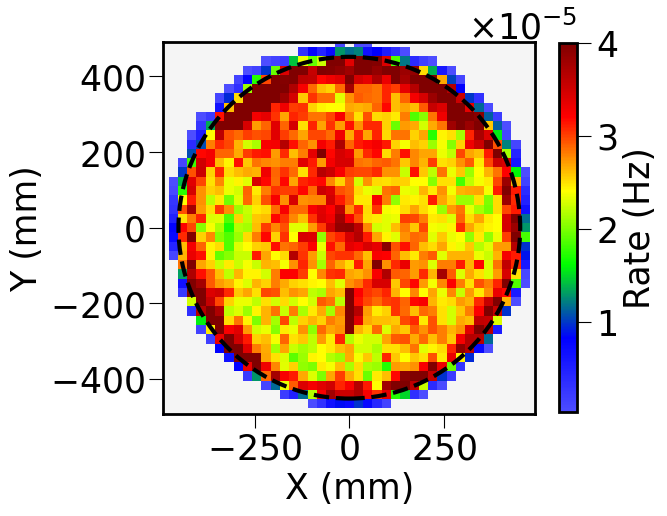

In [21]:
# Global
n_bins = 50

# Dataframe
data = DATAFRAMES['ras_on']['inclusive']
duration = DATAFRAMES['ras_on']['duration']

# Variables
X = data['X_bary'].unique()
Y = data['Y_bary'].unique()

# 2D histogram: normalized by corrected DAQ data taking time
XY_hit_map, ex, ey = crudo.pt.mapping(X, Y, xy_bins=n_bins, pos=True)
XY_rate            = XY_hit_map / duration                          # Normalized to rate      
XY_rate            = np.ma.masked_where(XY_rate == 0, XY_rate)      # Zero values masked
XY_rate            = np.clip(XY_rate, 0, 4e-5)

# ----- Plotting ----- #
plt.figure(figsize=(6, 6))
im = plt.pcolormesh(ex, ey, XY_rate.T, cmap=crudo.pt.custom_hsv, shading='auto')
cbar = plt.colorbar(im, label='Rate (Hz)', shrink=0.80)
cbar.formatter.set_powerlimits((-3, 3))

plt.xlabel('X (mm)')
plt.xlim(-crudo.pt.N100_rad, crudo.pt.N100_rad)
plt.ylabel('Y (mm)')
plt.ylim(-crudo.pt.N100_rad, crudo.pt.N100_rad)

# R-lim
plt.gca().add_patch(crudo.pt.plot_circle(R_UP, LINESTYLE='--'))
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
# plt.tight_layout()
plt.show()

## Inclusive/Fiducial (RAS:ON)

### Z Distribution

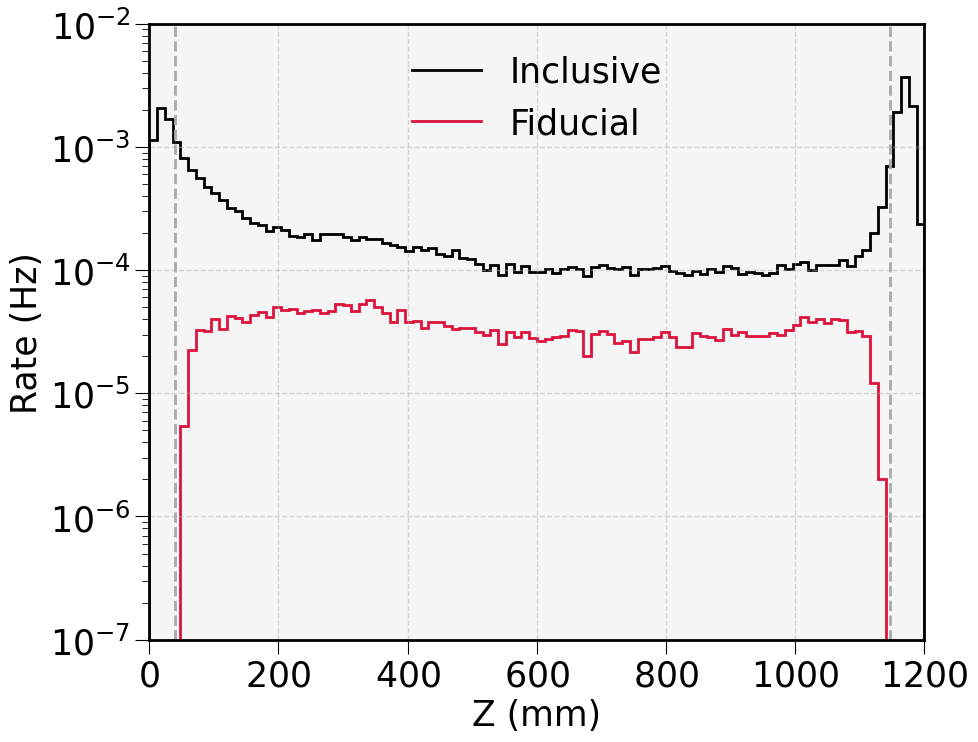

In [21]:
# Global
n_bins = 100

# Dataframes
# INCL_DF = DATAFRAMES['ras_on']['inclusive']
# FIDU_DF = DATAFRAMES['ras_on']['fiducial']
INCL_DF = INCLUSIVE_DF
FIDU_DF = FIDUCIAL_DF

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, plot_edges = np.histogram(INCL_DF['Z_bary'].unique(), bins=n_bins, range=(0, 1200))

for i, dataframe in enumerate([INCL_DF, FIDU_DF]):

    # Variable
    Z_evt = dataframe['Z_bary'].unique()

    # Histogram
    counts, bin_edges = np.histogram(Z_evt, bins=plot_edges)
    # rate = counts / DATAFRAMES['ras_on']['duration']    # in [Hz]
    rate = counts / DURATION    # in [Hz]

    # Labels
    if i == 0: label = 'Inclusive'
    else:      label = 'Fiducial'

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=2.0, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])

# Lines
plt.axvline(x=Z_LOW, c='darkgray', ls='--')
plt.axvline(x=Z_UP, c='darkgray', ls='--')

# ----- Styling ----- #
plt.xlabel('Z (mm)')
plt.xlim(0, 1200)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-7, 1e-2)
plt.yscale('log')
plt.legend(loc='upper center', framealpha=0)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Z_Bckg_Inclusive_Fiducial.pdf')
plt.show()

### $R^{2}$ Distribution

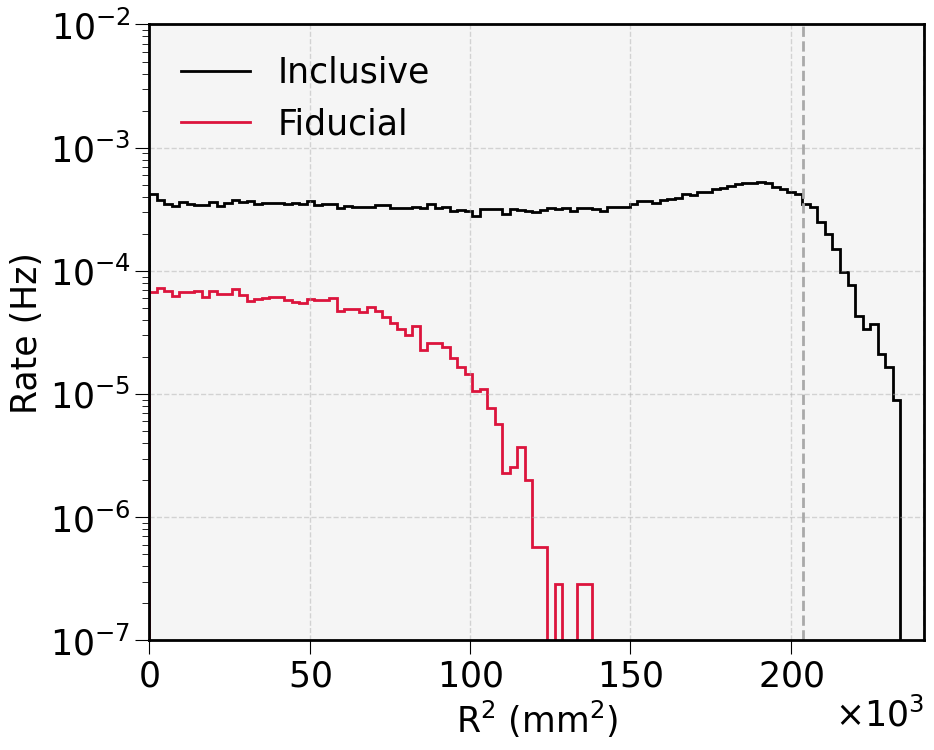

In [ ]:
# Global
n_bins = 100

# # Dataframes
# INCL_DF = DATAFRAMES['ras_on']['inclusive']
# FIDU_DF = DATAFRAMES['ras_on']['fiducial']

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
# Variables
X_evt = INCL_DF['X_bary'].unique()
Y_evt = INCL_DF['Y_bary'].unique()
R2_evt = X_evt**2 + Y_evt**2
_, plot_edges = np.histogram(R2_evt, bins=n_bins)

for i, dataframe in enumerate([INCL_DF, FIDU_DF]):

    # Variable
    X = dataframe['X_bary'].unique()
    Y = dataframe['Y_bary'].unique()
    R2 = X**2 + Y**2

    # Histogram
    counts, bin_edges = np.histogram(R2, bins=plot_edges)
    rate = counts / DATAFRAMES['ras_on']['duration']    # in [Hz]

    # Labels
    if i == 0: label = 'Inclusive'
    else:      label = 'Fiducial'

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=2.0, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])

# Lines
plt.axvline(x=R_UP**2, c='darkgray', ls='--')
plt.axvline(x=crudo.pt.N100_rad**2, c='darkgray', ls='--')

# ----- Styling ----- #
plt.xlabel(r'R$^{2}$ (mm$^{2}$)')
plt.xlim(0, crudo.pt.N100_rad**2)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-7, 1e-2)
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.yscale('log')
plt.legend(loc='upper left', framealpha=0)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/R2_Bckg_Inclusive_Fiducial.pdf')
plt.show()

In [27]:
# # Global
# n_bins = 100

# # ----- Define the Binning ----- #
# # Use the "Inclusive" region to define the binning
# # Dataframe
# data = ELEC_INCL_RAS_ON_DF.copy()

# # Variables
# X_evt = data['X_bary'].unique()
# Y_evt = data['Y_bary'].unique()
# R2_evt = X_evt**2 + Y_evt**2
# _, plot_edges = np.histogram(R2_evt, bins=n_bins)

# for i, dataframe in enumerate([ELEC_INCL_RAS_ON_DF, ELEC_FIDU_RAS_ON_DF]):

#     # Variable
#     X = dataframe['X_bary'].unique()
#     Y = dataframe['Y_bary'].unique()
#     R2 = X**2 + Y**2

#     # Histogram
#     counts, bin_edges = np.histogram(R2, bins=plot_edges)
#     rate = counts / (RAS_ON_CORRECTED_TIME)  # in [Hz]

#     # Labels
#     if i == 0:
#         label = 'Inclusive'
#     else:
#         label = 'Fiducial'

#     # ----- Plotting ----- #
#     plt.stairs(rate, bin_edges, label=f'{label}', 
#                fill=False, lw=1.5, ec=pt.hist_colors[i % len(pt.hist_colors)])

# # Lines
# plt.axvline(x=R_UP**2, c='darkgray', ls='--')
# plt.axvline(x=pt.N100_rad**2, c='darkgray', ls='--')

# # ----- Styling ----- #
# plt.xlabel(r'R$^{2}$ (mm$^{2}$)')
# plt.xlim(0, pt.N100_rad**2)
# plt.ylabel('Rate (Hz)')
# plt.ylim(1e-6, 4e-3)
# plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
# plt.yscale('log')
# plt.legend(loc='upper left')

# plt.grid(True)
# plt.gca().set_facecolor("whitesmoke")
# # plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/R2_Bckg_Inclusive_Fiducial.pdf')
# plt.show()

### E Distribution

Center of the DEP bin: 1.5900 MeV
Shift value: -0.0030 MeV

Inclusive in plot range | counts = 102861, corr. time = 3485614.53 s | Rate = 29.5101 mHz
Fiducial in plot range | counts = 10869, corr. time = 3485614.53 s | Rate = 3.1182 mHz


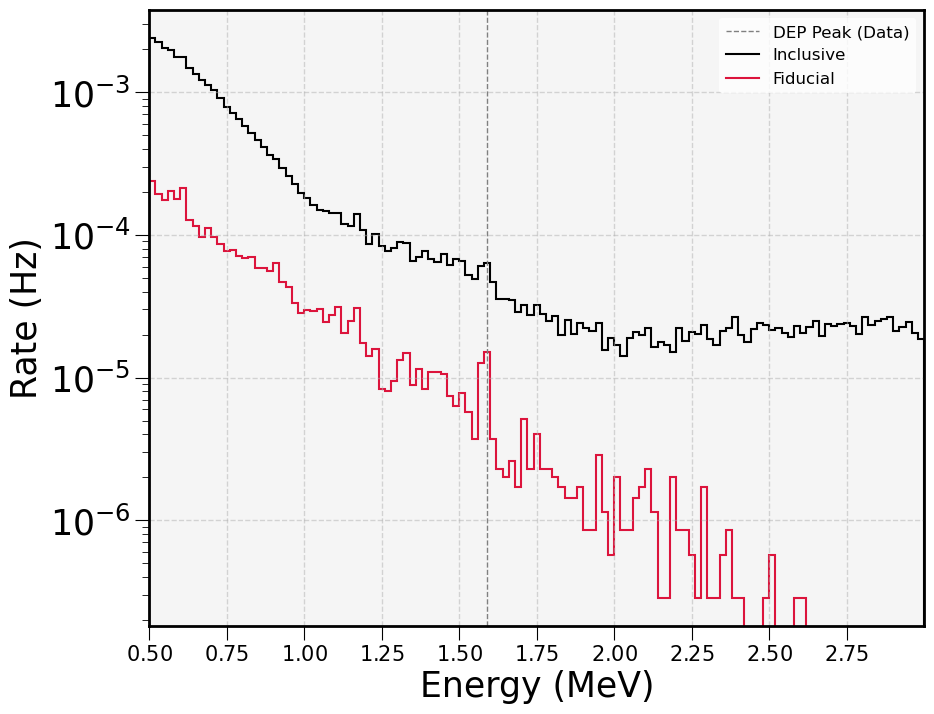

In [ ]:
# Global
n_bins = 125
DEP_VALUE = 1.593       # MeV

# Dataframes
# INCL_DF = DATAFRAMES['ras_on']['inclusive']
# FIDU_DF = DATAFRAMES['ras_on']['fiducial']

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, plot_edges = np.histogram(INCL_DF['E_final'].unique(), bins=n_bins, range=(INCL_DF['E_final'].min(), 3))

# ----- Shifting the Histogram ----- #
# Use the "Fiducial" data that includes DEP peak 
E_counts_fid, _ = np.histogram(FIDU_DF['E_final'].unique(), bins=plot_edges)
# Mask around DEP peak
mask = (plot_edges[:-1] >= 1.55) & (plot_edges[:-1] <= 1.75)  
bin_centers = (plot_edges[:-1] + plot_edges[1:]) / 2
# Find the bin with the highest count in the specified range
peak_bin_index  = np.argmax(E_counts_fid[mask])
peak_bin_center = bin_centers[mask][peak_bin_index]
print(f"Center of the DEP bin: {peak_bin_center:.4f} MeV")
shift_value = peak_bin_center - DEP_VALUE
print(f"Shift value: {shift_value:.4f} MeV\n")

for i, dataframe in enumerate([INCL_DF, FIDU_DF]):

    # Variable
    # E_evt = dataframe['E_evt_mev'].unique() - shift_value
    E_evt = dataframe['E_final'].unique()

    # Histogram
    counts, bin_edges = np.histogram(E_evt, bins=plot_edges)
    # rate = counts / (RAS_ON_CORRECTED_TIME)  # in [Hz]
    rate = counts / DURATION  # in [Hz]

    # Labels
    if i == 0:
        label = 'Inclusive'
    else:
        label = 'Fiducial'

    print(f"{label} in plot range | counts = {counts.sum()}, corr. time = {DURATION:.2f} s | Rate = {rate.sum()*1e3:.4f} mHz")

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=1.5, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])

# Lines
plt.axvline(peak_bin_center, c='gray', ls='--', lw=1.0, label='DEP Peak (Data)')
plt.axvline(x=DEP_VALUE, c='green', ls='--', lw=1.0, label='DEP Peak (Nominal)')
plt.axvline(1.5, c='gray', ls='--', lw=1.0, label='DEP Peak (Data)')

# ----- Styling ----- #
plt.xlabel('Energy (MeV)')
plt.xlim(0.5, 3)
plt.xticks(np.arange(0.5, 3.0, 0.25))
plt.xticks(fontsize=15)
plt.ylabel('Rate (Hz)')
# plt.ylim(1e-7, 1e-2)
plt.yscale('log')
plt.legend(loc='upper right', fontsize=12)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Energy_Bckg_Inclusive_Fiducial.pdf')
plt.show()

What are those _high energy_ events?! Yep those above $2.6$ MeV...

In [65]:
over_2_6_MeV_ids = ELEC_INCL_RAS_ON_DF.loc[ELEC_INCL_RAS_ON_DF['E_evt_mev'] >= 2.6, 'global_event'].unique()
over_2_6_MeV_df = ELEC_INCL_RAS_ON_DF.loc[ELEC_INCL_RAS_ON_DF['global_event'].isin(over_2_6_MeV_ids)].copy()

In [38]:
over_2_6_MeV_df

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region,E_evt_mev
2783,19224,26,5.455293e+05,2430,-19.738224,41.712058,641.697165,566.536940,742.304832,488.068255,...,1,1,558.804504,710.183553,3184,15625,2668,electron,tube,2.627941
2945,128977,36,1.017441e+06,7033,-93.362034,-0.138485,1182.809113,1164.532524,1201.831973,492.737969,...,1,1,253.671021,254.136011,7673,15625,2823,electron,cathode,4.893115
4497,1280169,25,5.849150e+05,1927,186.288550,-127.963307,278.428532,232.600987,325.284007,494.520987,...,1,1,484.453552,771.969892,2680,15625,4309,electron,tube,2.816992
4929,1605515,29,6.299369e+05,2371,345.482975,-73.429395,419.626082,374.786659,470.815608,495.788152,...,1,1,538.642456,794.186040,3236,15625,4729,electron,tube,3.033097
7226,1205928,26,5.566696e+05,1837,228.166937,-156.800447,200.617417,117.246317,289.042886,494.520987,...,1,1,431.895905,754.976870,2618,15625,6948,electron,tube,2.681414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000364,317175,25,5.927513e+05,2978,258.307199,-106.568080,947.326926,348.211643,1094.843583,498.571751,...,1,3,50.581512,75.083257,4820,15737,935341,electron,tube,3.536289
1000516,474465,25,5.743555e+05,2321,-211.806788,-256.676756,1185.960714,1168.719449,1202.574468,489.914917,...,1,1,737.726318,738.024051,3476,15737,935482,electron,cathode,2.766306
1001258,1235680,32,5.571820e+05,2184,13.784194,-38.340655,1186.023188,1168.042694,1205.437617,490.317200,...,1,1,746.278870,746.533412,3372,15737,936167,electron,cathode,2.683874
1002634,864191,26,6.399096e+05,2250,-6.411376,-24.019190,384.850940,323.278504,453.965083,498.469725,...,1,1,512.540344,796.178204,2980,15737,937423,electron,tube,3.080966


## RAS ON/OFF

### Z Distribution

RAS: off in range: counts = 3366, corr. time = 697798.63 s | Rate = 0.0048 Hz
RAS: on in range: counts = 12570, corr. time = 3485614.53 s | Rate = 0.0036 Hz


/tmp/ccortesp/ipykernel_266988/2815506879.py:38: RuntimeWarning: divide by zero encountered in divide
  Z_ras_on_off_hist['counts'] = rate_ras_on / rate_ras_off
/tmp/ccortesp/ipykernel_266988/2815506879.py:38: RuntimeWarning: invalid value encountered in divide
  Z_ras_on_off_hist['counts'] = rate_ras_on / rate_ras_off


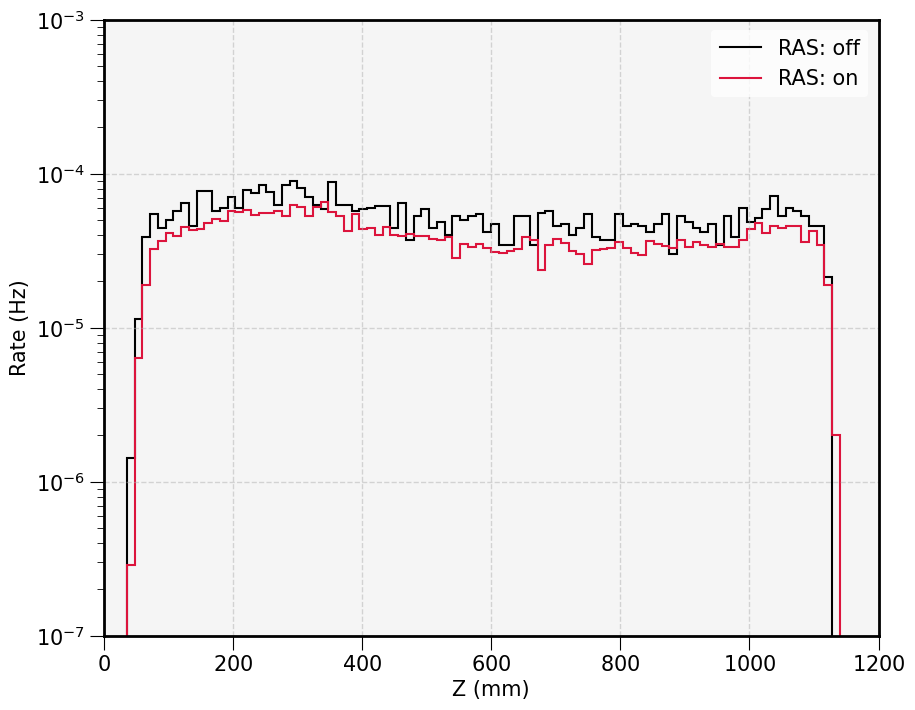

In [76]:
# Global
n_bins = 100

# Storage
Z_ras_on_off_hist = {}
rate_ras_on  = []
rate_ras_off = []

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, plot_edges = np.histogram(ELEC_FIDU_RAS_ON_DF['Z_bary'].unique(), bins=n_bins, range=(0, 1200))

for i, dataframe in enumerate([ELEC_FIDU_RAS_OFF_DF, ELEC_FIDU_RAS_ON_DF]):

    # Variable
    Z_evt = dataframe['Z_bary'].unique()

    # Histogram
    counts, bin_edges = np.histogram(Z_evt, bins=plot_edges)
    corr_time = RAS_OFF_CORRECTED_TIME if i == 0 else RAS_ON_CORRECTED_TIME
    rate = counts / (corr_time)  # in [Hz]

    # Labels
    if i == 0:
        label = 'RAS: off'
        rate_ras_off = rate
    else:
        label = 'RAS: on'
        rate_ras_on = rate

    print(f"{label} in range: counts = {counts.sum()}, corr. time = {corr_time:.2f} s | Rate = {rate.sum():.4f} Hz")

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=1.5, ec=pt.hist_colors[i % len(pt.hist_colors)])

Z_ras_on_off_hist['bin_edges'] = bin_edges
Z_ras_on_off_hist['counts'] = rate_ras_on / rate_ras_off

# ----- Styling ----- #
plt.xlabel('Z (mm)')
plt.xlim(0, 1200)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-7, 1e-3)
plt.yscale('log')
plt.legend(loc='upper right')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Z_Bckg_RAS_On_Off_Comparison.pdf')
plt.show()

Let's see the rate of both dataframes!

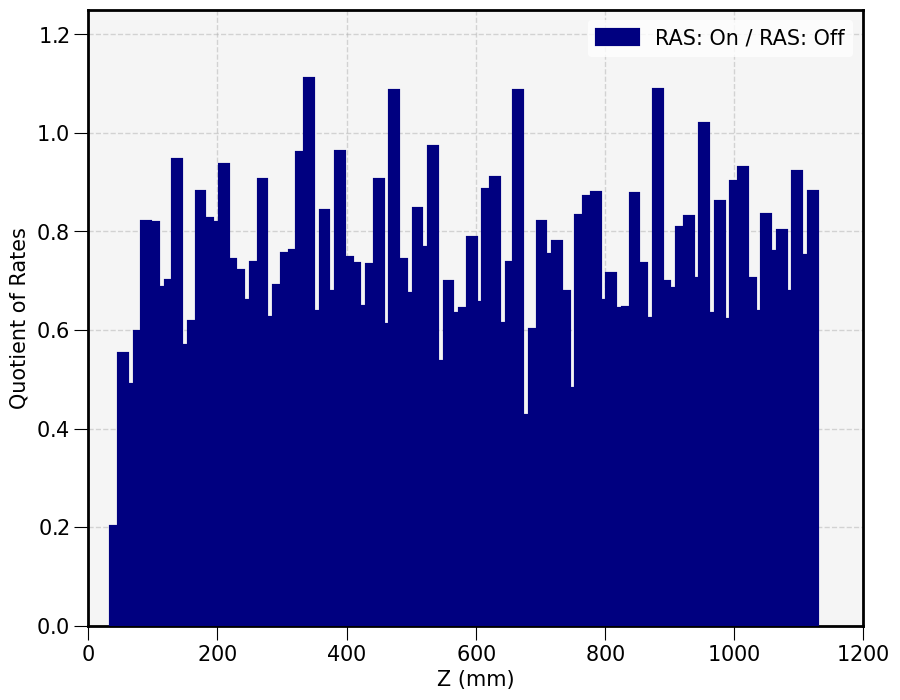

In [95]:
# Filter out NaN/Inf values
valid_counts = np.isfinite(Z_ras_on_off_hist['counts'])
filtered_counts = Z_ras_on_off_hist['counts'][valid_counts]
filtered_bin_edges = Z_ras_on_off_hist['bin_edges'][:-1][valid_counts]
bin_width = Z_ras_on_off_hist['bin_edges'][1] - Z_ras_on_off_hist['bin_edges'][0]

# ----- Plotting ----- #
plt.bar(filtered_bin_edges, filtered_counts, width=bin_width, 
       align='edge', label='RAS: On / RAS: Off', color='navy', edgecolor='navy', zorder=3)

# Styling
plt.xlabel('Z (mm)')
plt.xlim(0, 1200)
plt.ylabel('Quotient of Rates')
plt.ylim(0, 1.25)
# plt.yscale('log')
plt.legend(loc='upper right')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Z_Bckg_RAS_On_Off_Quotient.pdf')
plt.show()

### E Distribution

Center of the DEP bin: 1.68
Shift value: 0.08 MeV
RAS: off in range: counts = 2621, corr. time = 697798.63 s | Rate = 0.0038 Hz
RAS: on in range: counts = 9731, corr. time = 3485614.53 s | Rate = 0.0028 Hz


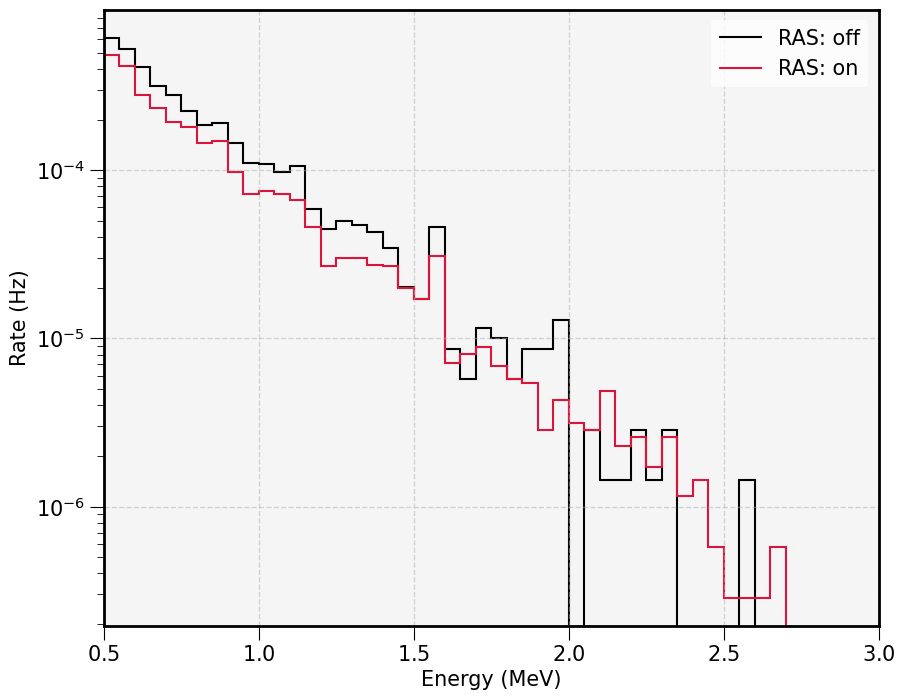

In [59]:
# Global
n_bins = 50
DEP_VALUE = 1.6       # MeV

# Storage
E_ras_on_off_hist = {}
rate_ras_on  = []
rate_ras_off = []

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, plot_edges = np.histogram(ELEC_FIDU_RAS_ON_DF['E_evt_mev'].unique(), bins=n_bins, range=(0.5, 3))

# ----- Shifting the Histogram ----- #
# Use the "Fiducial" data that includes DEP peak 
E_counts_fid, _ = np.histogram(ELEC_FIDU_RAS_ON_DF['E_evt_mev'].unique(), bins=plot_edges)
# Mask around DEP peak
mask = (plot_edges[:-1] >= 1.55) & (plot_edges[:-1] <= 1.75)  
bin_centers = (plot_edges[:-1] + plot_edges[1:]) / 2
# Find the bin with the highest count in the specified range
peak_bin_index  = np.argmax(E_counts_fid[mask])
peak_bin_center = bin_centers[mask][peak_bin_index]
print(f"Center of the DEP bin: {peak_bin_center:.2f}")
shift_value = peak_bin_center - DEP_VALUE
print(f"Shift value: {shift_value:.2f} MeV")

for i, dataframe in enumerate([ELEC_FIDU_RAS_OFF_DF, ELEC_FIDU_RAS_ON_DF]):

    # Variable
    E_evt = dataframe['E_evt_mev'].unique() - shift_value

    # Histogram
    counts, bin_edges = np.histogram(E_evt, bins=plot_edges)
    corr_time = RAS_OFF_CORRECTED_TIME if i == 0 else RAS_ON_CORRECTED_TIME
    rate = counts / (corr_time)  # in [Hz]

    # Labels
    if i == 0:
        label = 'RAS: off'
        rate_ras_off = rate
    else:
        label = 'RAS: on'
        rate_ras_on = rate

    print(f"{label} in range: counts = {counts.sum()}, corr. time = {corr_time:.2f} s | Rate = {rate.sum():.4f} Hz")

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=1.5, ec=pt.hist_colors[i % len(pt.hist_colors)])

E_ras_on_off_hist['bin_edges'] = bin_edges
E_ras_on_off_hist['counts'] = rate_ras_off - rate_ras_on

# ----- Styling ----- #
plt.xlabel('Energy (MeV)')
plt.xlim(0.5, 3)
plt.ylabel('Rate (Hz)')
# plt.ylim(1e-7, 1e-3)
plt.yscale('log')
plt.legend(loc='upper right')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Energy_Bckg_RAS_On_Off_Comparison.pdf')
plt.show()

And the quotient...

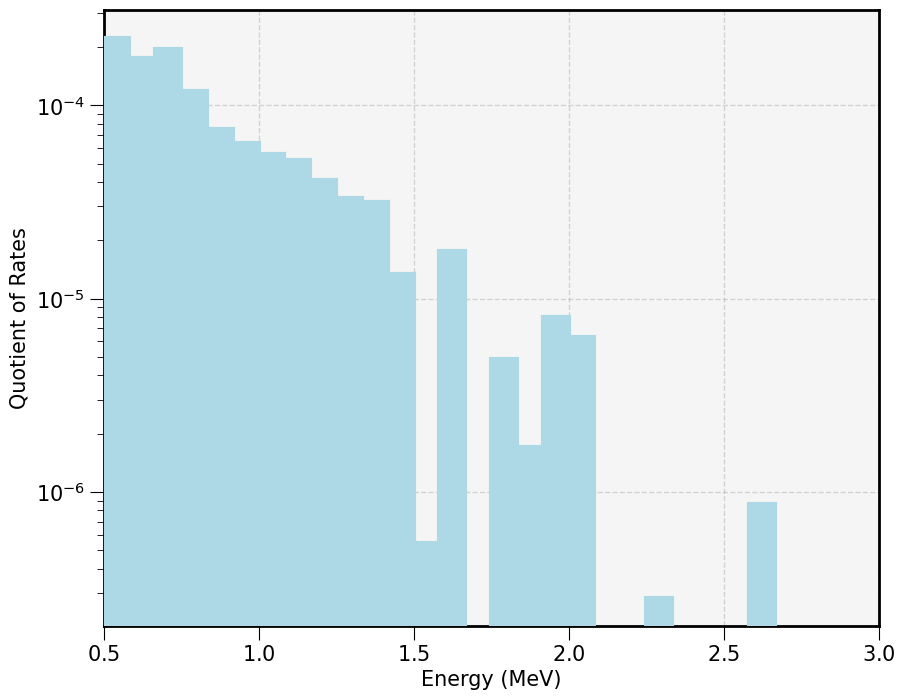

In [58]:
# Filter out NaN/Inf values
valid_counts = (E_ras_on_off_hist['counts'] >= 0) 
filtered_counts = E_ras_on_off_hist['counts'][valid_counts]
filtered_bin_edges = E_ras_on_off_hist['bin_edges'][:-1][valid_counts]
bin_width = E_ras_on_off_hist['bin_edges'][1] - E_ras_on_off_hist['bin_edges'][0]

# ----- Plotting ----- #
plt.bar(filtered_bin_edges, filtered_counts, width=bin_width, 
       align='edge', label='RAS: On / RAS: Off', color='lightblue', edgecolor='lightblue', zorder=3)

# Styling
plt.xlabel('Energy (MeV)')
plt.xlim(0.5, 3)
plt.ylabel('Quotient of Rates')
# plt.ylim(0, 2)
plt.yscale('log')
# plt.legend(loc='upper right')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Energy_Bckg_RAS_On_Off_Quotient.pdf')
plt.show()